# Lab: Adversarial Attacks and Adversarial Training


------------------------------------------------------
*Pablo M. Olmos pamartin@ing.uc3m.es*

------------------------------------------------------



## A canonical example: adversarial perturbations

The following figure comes from *Goodfellow et al., 2015* and illustrates how an imperceptible perturbation can completely change a modelâ€™s prediction.

![Adversarial example: panda to gibbon](https://uvadlc-notebooks.readthedocs.io/en/latest/_images/adversarial_example.svg)

From left to right:

- **Original image**: correctly classified as *panda*
- **Adversarial noise**: visually imperceptible (amplified for display in the paper)
- **Adversarial image**: classified as *gibbon* with high confidence

This example highlights that adversarial attacks do not rely on semantic changes, but on exploiting vulnerabilities in the modelâ€™s decision boundaries.


## What is an adversarial example?

An **adversarial example** is a slightly modified input that causes a neural
network to make an incorrect prediction.

Given an input image $x$ and a classifier $f_\theta$, we search for a small
perturbation $\delta$ such that $f_\theta(x) \neq f_\theta(x + \delta)$
while keeping the perturbation imperceptibly small:

$\|\delta\|_\infty \le \varepsilon$

The adversarial image is defined as

$x_{\text{adv}} = \text{clip}(x + \delta)$

where the clipping operation ensures that pixel values remain in the valid
range (e.g. $[0,1]$).


## Threat model: White-box attacks

In this notebook we assume a **white-box attacker**, meaning:

- The model architecture is known
- The model parameters $\theta$ are known
- Gradients $\nabla_x \mathcal{L}(f_\theta(x), y)$ can be computed

This setting allows us to design efficient gradient-based attacks.


## Fast Gradient Sign Method (FGSM)

The **Fast Gradient Sign Method (FGSM)** is a single-step adversarial attack.

Given a loss function $\mathcal{L}$, the perturbation is computed as

$\delta = \varepsilon \cdot \text{sign}\left(\nabla_x \mathcal{L}(f_\theta(x), y)\right)$

The adversarial example is then

$x_{\text{adv}} = \text{clip}(x + \delta)$

Key properties:

- Very fast (one gradient computation)
- Often sufficient to fool standard CNNs
- Serves as the basis for stronger iterative attacks


## Intuition behind FGSM

The gradient $\nabla_x \mathcal{L}(f_\theta(x), y)$ indicates how each pixel
should change to **increase the loss**.

FGSM takes the **sign** of this gradient and pushes each pixel to its maximum
allowed change $\varepsilon$ in the direction that most increases the loss.

Even though the perturbation is small, it is coordinated across all pixels,
which makes it highly effective.


## Projected Gradient Descent (PGD)

**Projected Gradient Descent (PGD)** is an iterative version of FGSM.

Starting from the original image $x^{(0)} = x$, we repeat

$x^{(t+1)} = \Pi_{B_\varepsilon(x)}\left(x^{(t)} + \alpha \cdot \text{sign}\left(\nabla_x \mathcal{L}(f_\theta(x^{(t)}), y)\right)\right)$

where:

- $\alpha$ is the step size
- $\Pi_{B_\varepsilon(x)}$ projects back onto the $\ell_\infty$ ball of radius
  $\varepsilon$ around the original image

PGD is considered a **strong first-order adversary** and is widely used for
robustness evaluation.


### How projection works (intuitively)

For each pixel independently:

- If it lies within the interval $[x_i - \varepsilon,\; x_i + \varepsilon]$, it is left unchanged.
- If it is larger than $x_i + \varepsilon$, it is clamped down to $x_i + \varepsilon$.
- If it is smaller than $x_i - \varepsilon$, it is clamped up to $x_i - \varepsilon$.

As a result, the projection step is simply an element-wise clipping operation that keeps the adversarial example within an $\ell_\infty$ distance $\varepsilon$ of the original image.


## Targeted vs untargeted attacks

### Untargeted attack

The goal is simply to cause **any misclassification**:

$\max_\delta \; \mathcal{L}(f_\theta(x + \delta), y)$

### Targeted attack

The goal is to force the model to predict a **specific target class**
$y_{\text{target}}$:

$\min_\delta \; \mathcal{L}(f_\theta(x + \delta), y_{\text{target}})$

Targeted attacks are typically harder and require stronger perturbations or
more iterations.


## Accuracy vs perturbation strength

A common way to evaluate adversarial robustness is to measure test accuracy
as a function of $\varepsilon$:

- $\varepsilon = 0$: clean accuracy
- Increasing $\varepsilon$: stronger attacks
- Rapid accuracy drop indicates lack of robustness

This evaluation helps visualize how fragile standard CNNs are to adversarial
perturbations.


## Key takeaways

- Adversarial examples exploit the **local linearity** of neural networks
- FGSM is fast and simple but already very effective
- PGD is stronger and often considered the "gold standard" attack
- Standard CNNs trained normally are **not robust** to adversarial noise

Adversarial robustness is an important consideration when deploying deep
learning models in safety-critical applications.


## Setup (GPU)

This notebook will use **one GPU** if available. We set `CUDA_VISIBLE_DEVICES=0` and use `cuda:0`.


In [1]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# --- GPU selection: use only ONE GPU (GPU 0) ---
# Keeping device selection explicit makes the notebook easier to reproduce in
# class and avoids silently spreading work across multiple GPUs.
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")

def set_seed(seed=0):
    """
    High-level overview:
    Make the experiment deterministic enough to compare standard and robust
    training runs without random variation dominating the conclusions.
    """
    # Seed Python's built-in RNG used by some data-loading utilities.
    random.seed(seed)
    # Seed NumPy so any array-level randomness matches across runs.
    np.random.seed(seed)
    # Seed CPU-side PyTorch operations.
    torch.manual_seed(seed)
    # Seed every visible CUDA device for reproducible GPU behavior.
    torch.cuda.manual_seed_all(seed)

# Set one global seed before creating models or loading data.
set_seed(0)

# Prefer the first CUDA device when available; otherwise fall back to CPU.
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    # Explicitly pin the notebook to GPU 0 so later cells use the same device.
    torch.cuda.set_device(0)
    # Benchmark mode usually speeds up convolutions when input shapes are fixed.
    torch.backends.cudnn.benchmark = True
    print("Using GPU:", torch.cuda.get_device_name(0))
else:
    print("Using CPU")


Using GPU: NVIDIA GeForce RTX 3050 4GB Laptop GPU


In [4]:
batch_size = 128

# Keep MNIST in the original [0, 1] pixel range because the attack code clips
# directly in pixel space.
transform = transforms.Compose([
    transforms.ToTensor(),  # Converts PIL images to float tensors in [0, 1].
])

# Download the standard MNIST train/test split.
train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

# DataLoader settings:
# - pin_memory helps GPU transfers.
# - notebooks on Windows are often more stable with num_workers=0.
pin_memory = (device.type == "cuda")
num_workers = 4 if (os.name != "nt") else 0
num_workers = min(num_workers, os.cpu_count() or 2)

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,   # Shuffle training data so each epoch sees a fresh order.
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=(num_workers > 0),
)

test_loader = DataLoader(
    test_ds,
    batch_size=batch_size,
    shuffle=False,  # Test data stays in a fixed order for reproducibility.
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=(num_workers > 0),
)

# Inspect one batch to confirm the expected tensor shapes before training.
x0, y0 = next(iter(train_loader))
print("Batch:", x0.shape, y0.shape)


Batch: torch.Size([128, 1, 28, 28]) torch.Size([128])


# Part I: Standard Training Baseline

This section begins the **standard training** workflow for the small MNIST CNN.

We will:

- define the baseline model
- train it with cross-entropy on clean data
- evaluate clean and robust accuracy
- measure calibration with NLL, ECE, and reliability diagrams


In [5]:
class SmallCNN(nn.Module):
    def __init__(self):
        """
        High-level overview:
        Build a compact convolutional classifier for MNIST that is small
        enough to train quickly while still being expressive enough to show
        meaningful robustness and calibration behavior.
        """
        super().__init__()
        # First block learns low-level local features such as strokes and edges.
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        # Second block increases channel capacity before flattening.
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        # Fully connected layers map the extracted features to class logits.
        self.fc1   = nn.Linear(64 * 7 * 7, 128)
        self.fc2   = nn.Linear(128, 10)

    def forward(self, x):
        """
        High-level overview:
        Transform an input image into class logits through two convolutional
        stages followed by a small multilayer perceptron head.
        """
        # Stage 1: convolve, apply a nonlinearity, then downsample 28 -> 14.
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        # Stage 2: repeat the same pattern and downsample 14 -> 7.
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        # Flatten spatial feature maps into a single vector per image.
        x = x.view(x.size(0), -1)
        # Hidden layer mixes features across channels and spatial positions.
        x = F.relu(self.fc1(x))
        # Return raw logits; the loss will apply softmax internally.
        return self.fc2(x)

# Create the standard clean-trained baseline model for all later comparisons.
model = SmallCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


In [6]:
def train_one_epoch(model, loader, optimizer):
    """
    High-level overview:
    Run one full pass of standard supervised training using cross-entropy on
    clean inputs and return the average loss over the epoch.
    """
    model.train()
    total_loss, total = 0.0, 0

    for x, y in loader:
        # Move the current mini-batch to the selected device.
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        # Clear stale gradients before computing a new backward pass.
        optimizer.zero_grad(set_to_none=True)
        # Forward pass on clean images.
        logits = model(x)
        # Standard training objective requested in the project statement.
        loss = F.cross_entropy(logits, y)
        # Backpropagate the loss through the network.
        loss.backward()
        # Update model parameters with Adam.
        optimizer.step()

        # Accumulate a sample-weighted loss average for logging.
        total_loss += loss.item() * x.size(0)
        total += x.size(0)

    return total_loss / total

@torch.no_grad()
def eval_accuracy(model, loader):
    """
    High-level overview:
    Measure clean classification accuracy on a dataloader without building
    gradients, which keeps evaluation fast and memory efficient.
    """
    model.eval()
    correct, total = 0, 0

    for x, y in loader:
        # Evaluation still needs tensors on the same device as the model.
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        # Convert logits to hard class predictions with argmax.
        pred = model(x).argmax(1)
        correct += (pred == y).sum().item()
        total += x.size(0)

    return correct / total

# Quick baseline training: MNIST converges reasonably well in only a few epochs.
standard_epochs = 3
for epoch in range(standard_epochs):
    loss = train_one_epoch(model, train_loader, optimizer)
    acc = eval_accuracy(model, test_loader)
    print(f"[standard-train] epoch={epoch+1} loss={loss:.4f} test_acc={acc*100:.2f}%")


epoch=1 loss=0.2394 test_acc=97.92%
epoch=2 loss=0.0588 test_acc=98.51%
epoch=3 loss=0.0401 test_acc=98.78%


In [7]:
def clamp01(x):
    """
    High-level overview:
    Enforce the valid image range after adversarial perturbations so attacks do
    not create impossible MNIST pixel values outside [0, 1].
    """
    return torch.clamp(x, 0.0, 1.0)

@torch.no_grad()
def predict(model, x):
    """
    High-level overview:
    Produce hard predictions for a batch of images so visualization cells can
    display the model's decision before and after an attack.
    """
    model.eval()
    logits = model(x)
    return logits.argmax(dim=1)

def show_batch(images, labels=None, preds=None, n=8, title=None):
    """
    High-level overview:
    Visualize a small batch of images together with optional true labels and
    model predictions to qualitatively inspect attack effects.
    """
    # Move images back to CPU because matplotlib expects NumPy-compatible data.
    images = images.detach().cpu()
    n = min(n, images.size(0))
    fig, axes = plt.subplots(1, n, figsize=(1.8 * n, 2.0))
    if n == 1:
        axes = [axes]

    for i in range(n):
        # MNIST is grayscale, so we display the single channel with cmap="gray".
        axes[i].imshow(images[i, 0], cmap="gray", vmin=0, vmax=1)
        axes[i].axis("off")
        title_lines = []
        if labels is not None:
            title_lines.append(f"y={int(labels[i])}")
        if preds is not None:
            title_lines.append(f"p={int(preds[i])}")
        axes[i].set_title("\n".join(title_lines), fontsize=10)

    if title:
        fig.suptitle(title)
    plt.show()

def l_inf_norm(x_adv, x):
    """
    High-level overview:
    Compute the per-sample L-infinity perturbation size to verify that FGSM and
    PGD stay inside the intended epsilon-ball constraint.
    """
    # Flatten each image and take the maximum absolute pixel difference.
    return (x_adv - x).abs().view(x.size(0), -1).max(dim=1).values


In [6]:
def fgsm_attack(model, x, y, eps, targeted=False, y_target=None):
    """
    High-level overview:
    Generate a one-step adversarial example by moving each pixel in the sign
    direction of the loss gradient, which makes FGSM fast but still effective.
    """
    # Use evaluation mode so dropout/batch-norm-like behavior stays fixed while
    # crafting the adversarial perturbation.
    model.eval()
    # Start from the clean image and enable gradients with respect to inputs.
    x_adv = x.clone().detach().requires_grad_(True)

    # Compute logits for the current adversarial candidate.
    logits = model(x_adv)

    if targeted:
        assert y_target is not None, "Provide y_target for targeted FGSM."
        # For targeted attacks we minimize the target-class loss.
        loss = F.cross_entropy(logits, y_target)
        grad_sign = torch.autograd.grad(loss, x_adv)[0].sign()
        x_adv = x_adv - eps * grad_sign
    else:
        # For untargeted attacks we maximize the true-label loss.
        loss = F.cross_entropy(logits, y)
        grad_sign = torch.autograd.grad(loss, x_adv)[0].sign()
        x_adv = x_adv + eps * grad_sign

    # Project back to the valid image range after the perturbation step.
    x_adv = clamp01(x_adv.detach())
    return x_adv


## Part I.A: Visual Attack Examples

Before running full-dataset evaluation, these cells show what FGSM and PGD perturbations look like on a sample batch.


Clean acc on this batch: 0.9921875
FGSM  acc on this batch: 0.578125
Max L_inf in batch: 0.15000003576278687


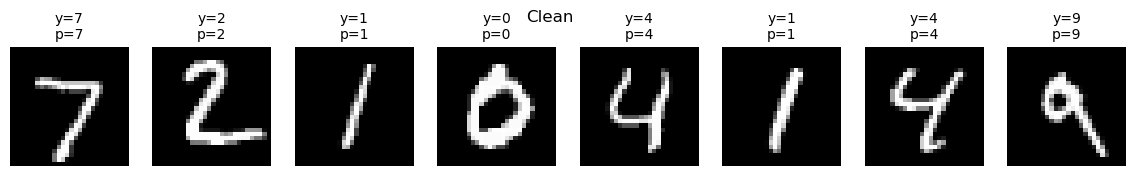

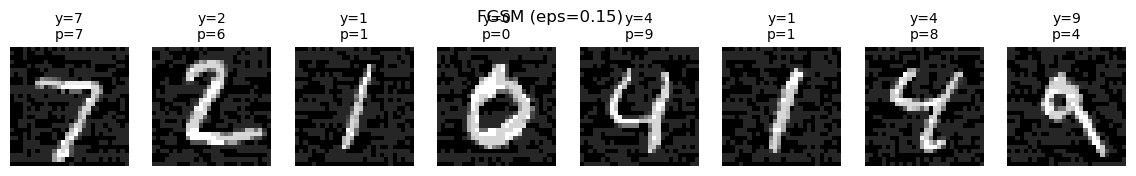

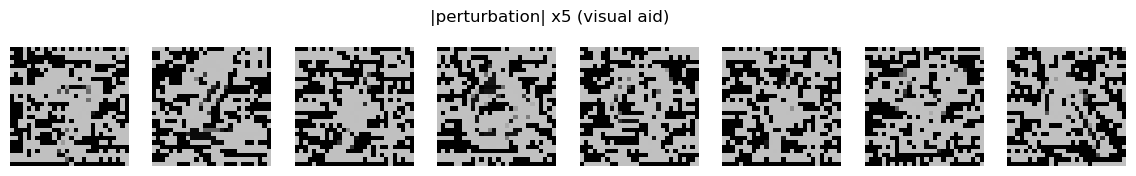

In [7]:
x, y = next(iter(test_loader))
x, y = x.to(device), y.to(device)

with torch.no_grad():
    p_clean = predict(model, x)

eps = 0.15
x_fgsm = fgsm_attack(model, x, y, eps=eps, targeted=False)

with torch.no_grad():
    p_adv = predict(model, x_fgsm)

print("Clean acc on this batch:", (p_clean == y).float().mean().item())
print("FGSM  acc on this batch:", (p_adv == y).float().mean().item())
print("Max L_inf in batch:", l_inf_norm(x_fgsm, x).max().item())

show_batch(x[:8], labels=y[:8], preds=p_clean[:8], title="Clean")
show_batch(x_fgsm[:8], labels=y[:8], preds=p_adv[:8], title=f"FGSM (eps={eps})")
show_batch((x_fgsm - x).abs()[:8] * 5, title="|perturbation| x5 (visual aid)")


In [8]:
def pgd_attack(model, x, y, eps, alpha, steps, random_start=True,
               targeted=False, y_target=None):
    """
    High-level overview:
    Run projected gradient descent inside an L-infinity ball around the clean
    image, giving a much stronger robustness evaluation than single-step FGSM.
    """
    model.eval()

    # Keep a detached copy of the clean image because projection is always
    # defined relative to the original sample, not the latest iterate.
    x_orig = x.detach()
    if random_start:
        # Random starts make PGD harder to overfit and usually strengthen it.
        x_adv = x_orig + (2 * torch.rand_like(x_orig) - 1.0) * eps
        x_adv = clamp01(x_adv)
    else:
        x_adv = x_orig.clone()

    for _ in range(steps):
        # Re-enable gradients at every iteration on the latest adversarial point.
        x_adv = x_adv.clone().detach().requires_grad_(True)
        logits = model(x_adv)

        if targeted:
            assert y_target is not None, "Provide y_target for targeted PGD."
            loss = F.cross_entropy(logits, y_target)
            grad = torch.autograd.grad(loss, x_adv)[0]
            # Targeted PGD descends toward the chosen target class.
            x_adv = x_adv - alpha * grad.sign()
        else:
            loss = F.cross_entropy(logits, y)
            grad = torch.autograd.grad(loss, x_adv)[0]
            # Untargeted PGD ascends the true-label loss.
            x_adv = x_adv + alpha * grad.sign()

        # Project the perturbation back into the L-infinity epsilon-ball.
        delta = torch.clamp(x_adv - x_orig, min=-eps, max=eps)
        x_adv = clamp01(x_orig + delta)

    return x_adv.detach()


PGD acc on this batch: 0.0078125
Max L_inf in batch: 0.20000001788139343


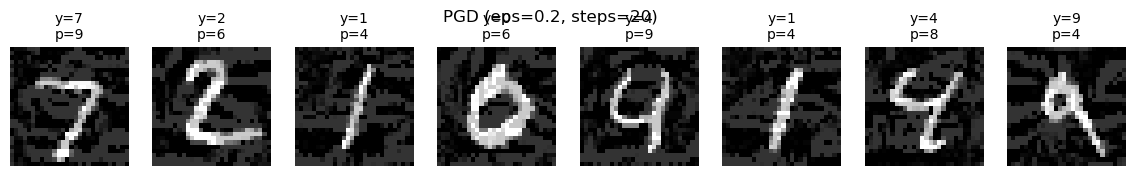

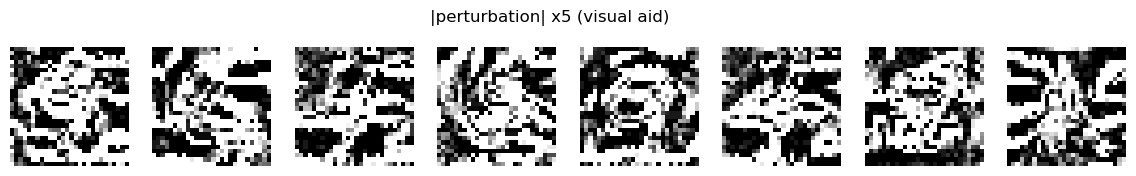

In [9]:
eps = 0.20
alpha = 0.02
steps = 20

x_pgd = pgd_attack(model, x, y, eps=eps, alpha=alpha, steps=steps, random_start=True)

with torch.no_grad():
    p_pgd = predict(model, x_pgd)

print("PGD acc on this batch:", (p_pgd == y).float().mean().item())
print("Max L_inf in batch:", l_inf_norm(x_pgd, x).max().item())

show_batch(x_pgd[:8], labels=y[:8], preds=p_pgd[:8], title=f"PGD (eps={eps}, steps={steps})")
show_batch((x_pgd - x).abs()[:8] * 5, title="|perturbation| x5 (visual aid)")


In [10]:
@torch.no_grad()
def eval_clean(model, loader):
    """
    High-level overview:
    Compute clean test accuracy, which serves as the standard generalization
    baseline before comparing adversarial robustness.
    """
    model.eval()
    correct, total = 0, 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        pred = model(x).argmax(1)
        correct += (pred == y).sum().item()
        total += x.size(0)

    return correct / total

def eval_under_attack(model, loader, attack_fn):
    """
    High-level overview:
    Measure robust accuracy by attacking each batch first and then checking how
    often the model still predicts the true class.
    """
    model.eval()
    correct, total = 0, 0

    for x, y in loader:
        # Robust evaluation needs gradients inside attack_fn, so do not wrap the
        # full loop in torch.no_grad().
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        x_adv = attack_fn(x, y)
        with torch.no_grad():
            pred = model(x_adv).argmax(1)
        correct += (pred == y).sum().item()
        total += x.size(0)

    return correct / total


In [11]:
eps_list = [0.0, 0.05, 0.10, 0.15, 0.20, 0.25]

clean_acc = eval_clean(model, test_loader)
print("Clean accuracy:", clean_acc)

fgsm_accs = []
pgd_accs  = []

for eps in eps_list:
    if eps == 0.0:
        fgsm_accs.append(clean_acc)
        pgd_accs.append(clean_acc)
        continue

    fgsm_acc = eval_under_attack(
        model, test_loader,
        attack_fn=lambda x, y, eps=eps: fgsm_attack(model, x, y, eps=eps)
    )
    pgd_acc = eval_under_attack(
        model, test_loader,
        attack_fn=lambda x, y, eps=eps: pgd_attack(model, x, y, eps=eps, alpha=eps/10, steps=20)
    )
    fgsm_accs.append(fgsm_acc)
    pgd_accs.append(pgd_acc)
    print(f"eps={eps:.2f}  FGSM={fgsm_acc*100:.2f}%  PGD={pgd_acc*100:.2f}%")


Clean accuracy: 0.9868
eps=0.05  FGSM=95.46%  PGD=94.46%
eps=0.10  FGSM=85.78%  PGD=75.78%
eps=0.15  FGSM=65.50%  PGD=29.66%
eps=0.20  FGSM=38.36%  PGD=2.76%
eps=0.25  FGSM=16.26%  PGD=0.01%


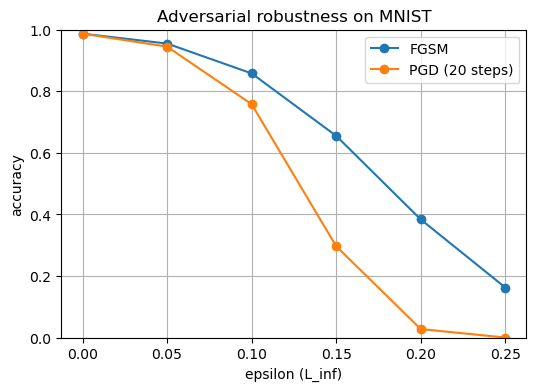

In [12]:
plt.figure(figsize=(6,4))
plt.plot(eps_list, fgsm_accs, marker="o", label="FGSM")
plt.plot(eps_list, pgd_accs,  marker="o", label="PGD (20 steps)")
plt.xlabel("epsilon (L_inf)")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.grid(True)
plt.legend()
plt.title("Adversarial robustness on MNIST")
plt.show()


## Part I.B: Standard Model Robustness Evaluation

This subsection measures how the clean-trained model performs on the test set under clean inputs, FGSM, and PGD attacks across different perturbation strengths.


## Comparison of attacks: accuracy vs $\varepsilon$

We compare test accuracy under different **white-box** adversarial attacks as a function of the perturbation budget $\varepsilon$ (using an $\ell_\infty$ constraint).

For each $\varepsilon$ we generate adversarial examples $x_{\text{adv}}$ and report:

- **Clean accuracy** (no attack)
- **FGSM** accuracy (1-step)
- **PGD** accuracy for different numbers of steps (stronger attacks)

Typically, as $\varepsilon$ increases and as the number of PGD steps increases, accuracy decreases.

attack,Clean,FGSM,PGD-10,PGD-40
epsilon,,,,
0.000000,0.987,nan,nan,nan
0.050000,0.987,0.955,0.945,0.945
0.100000,0.987,0.858,0.762,0.748
0.150000,0.987,0.655,0.313,0.266
0.200000,0.987,0.384,0.029,0.019
0.250000,0.987,0.163,0.000,0.000


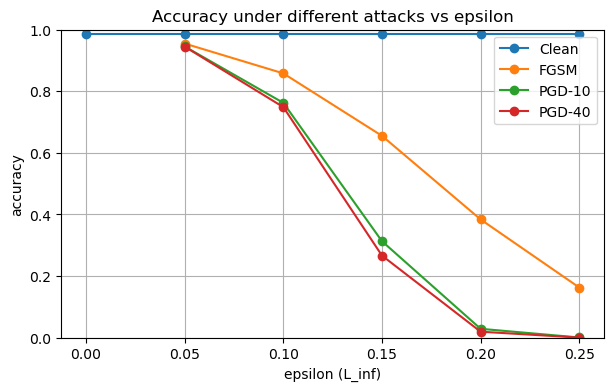

In [17]:
import pandas as pd

def attack_suite(model, eps, pgd_steps_list=(10, 40)):
    """
    High-level overview:
    Build a named collection of attack callables for a single epsilon so we
    can sweep multiple robustness tests with a shared interface.
    """
    suite = {}
    # Include the clean baseline in the same table for easier comparison.
    suite["Clean"] = lambda x, y: x
    if eps > 0:
        suite[f"FGSM (eps={eps:.2f})"] = lambda x, y: fgsm_attack(model, x, y, eps=eps)
        for steps in pgd_steps_list:
            # A common heuristic is to scale the PGD step size with epsilon.
            alpha = eps / 4 if eps > 0 else 0.0
            suite[f"PGD-{steps} (eps={eps:.2f})"] = lambda x, y, a=alpha, s=steps: pgd_attack(
                model, x, y, eps=eps, alpha=a, steps=s, random_start=True
            )
    return suite

def eval_attack_accuracy(model, loader, attack_fn):
    """
    High-level overview:
    Evaluate accuracy for one specific attack function so broader sweeps can be
    expressed as repeated calls to this smaller helper.
    """
    model.eval()
    correct, total = 0, 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        x_adv = attack_fn(x, y)
        with torch.no_grad():
            pred = model(x_adv).argmax(1)
        correct += (pred == y).sum().item()
        total += x.size(0)

    return correct / total

def sweep_attacks(model, loader, eps_list, pgd_steps_list=(10, 40), max_batches=None):
    """
    High-level overview:
    Produce a tidy table of accuracies across epsilon values and attack types so
    robustness curves can be plotted directly from the returned DataFrame.
    """
    rows = []

    for eps in eps_list:
        suite = attack_suite(model, eps, pgd_steps_list=pgd_steps_list)
        for name, fn in suite.items():
            # Optionally allow partial sweeps when fast iteration is more
            # important than a full-dataset measurement.
            if max_batches is None:
                acc = eval_attack_accuracy(model, loader, fn)
            else:
                model.eval()
                correct, total = 0, 0
                for bi, (x, y) in enumerate(loader):
                    if bi >= max_batches:
                        break
                    x = x.to(device, non_blocking=True)
                    y = y.to(device, non_blocking=True)
                    x_adv = fn(x, y)
                    with torch.no_grad():
                        pred = model(x_adv).argmax(1)
                    correct += (pred == y).sum().item()
                    total += x.size(0)
                acc = correct / total

            rows.append({
                "epsilon": float(eps),
                "attack": name.split(" (eps=")[0],
                "accuracy": acc,
            })

    df = pd.DataFrame(rows)
    return df

# --- run sweep (set max_batches to e.g. 50 if you want it faster) ---
eps_list = [0.0, 0.05, 0.10, 0.15, 0.20, 0.25]
df_attacks = sweep_attacks(model, test_loader, eps_list, pgd_steps_list=(10, 40), max_batches=None)

# Pretty table: rows=epsilon, cols=attack
table = df_attacks.pivot_table(index="epsilon", columns="attack", values="accuracy")
display(table.style.format("{:.3f}"))

# Plot the robustness degradation as epsilon increases.
plt.figure(figsize=(7, 4))
for col in table.columns:
    plt.plot(table.index, table[col], marker="o", label=col)
plt.xlabel("epsilon (L_inf)")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.grid(True)
plt.legend()
plt.title("Accuracy under different attacks vs epsilon")
plt.show()


## Part I.C: Standard Model Calibration Evaluation

This subsection studies whether the clean-trained model is well calibrated on clean and adversarial examples using NLL, ECE, and reliability diagrams.


## Standard training: robustness and calibration

For the project, the clean-trained MNIST CNN should be evaluated not only on
clean and adversarial accuracy, but also on **probabilistic calibration**.

In the next cells we compute:

- Clean accuracy
- FGSM robust accuracy
- PGD robust accuracy
- Negative Log-Likelihood (NLL)
- Expected Calibration Error (ECE)
- Reliability diagrams for clean, FGSM, and PGD predictions

This gives us a first view of how predictive confidence changes once the model
is exposed to stronger attacks.


In [ ]:
def collect_logits_and_labels(model, loader, attack_fn=None, max_batches=None):
    """
    High-level overview:
    Gather logits and labels for clean or attacked inputs so downstream metric
    functions can reuse one shared evaluation pass.
    """
    model.eval()
    logits_list = []
    labels_list = []

    for batch_idx, (x, y) in enumerate(loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        # Apply the attack only when one is provided; otherwise keep inputs clean.
        if attack_fn is not None:
            x_eval = attack_fn(x, y)
        else:
            x_eval = x

        with torch.no_grad():
            logits = model(x_eval)

        # Move results to CPU so metric computation is device-agnostic.
        logits_list.append(logits.cpu())
        labels_list.append(y.cpu())

    return torch.cat(logits_list, dim=0), torch.cat(labels_list, dim=0)

def compute_nll(logits, labels):
    """
    High-level overview:
    Compute negative log-likelihood, which rewards models that assign high
    probability to the correct class and penalizes overconfident mistakes.
    """
    return F.cross_entropy(logits, labels).item()

def compute_ece(logits, labels, n_bins=15):
    """
    High-level overview:
    Estimate expected calibration error by comparing confidence and accuracy
    inside confidence bins across the test set.
    """
    probs = torch.softmax(logits, dim=1)
    confidences, predictions = probs.max(dim=1)
    accuracies = predictions.eq(labels)

    # Bin boundaries partition confidence values from 0 to 1.
    bin_edges = torch.linspace(0.0, 1.0, steps=n_bins + 1)
    ece = torch.zeros(1, dtype=torch.float32)

    for bin_idx in range(n_bins):
        # The last bin is closed on the right so confidence 1.0 is included.
        lower = bin_edges[bin_idx]
        upper = bin_edges[bin_idx + 1]
        if bin_idx == n_bins - 1:
            in_bin = (confidences >= lower) & (confidences <= upper)
        else:
            in_bin = (confidences >= lower) & (confidences < upper)

        prop_in_bin = in_bin.float().mean()
        if prop_in_bin.item() > 0:
            accuracy_in_bin = accuracies[in_bin].float().mean()
            confidence_in_bin = confidences[in_bin].mean()
            ece += torch.abs(confidence_in_bin - accuracy_in_bin) * prop_in_bin

    return ece.item()

def reliability_diagram_from_logits(logits, labels, n_bins=15, ax=None, title="Reliability diagram"):
    """
    High-level overview:
    Plot empirical accuracy against predicted confidence so overconfidence and
    underconfidence can be diagnosed visually.
    """
    probs = torch.softmax(logits, dim=1)
    confidences, predictions = probs.max(dim=1)
    accuracies = predictions.eq(labels)
    bin_edges = torch.linspace(0.0, 1.0, steps=n_bins + 1)

    bin_centers = []
    bin_accuracies = []
    bin_confidences = []

    for bin_idx in range(n_bins):
        lower = bin_edges[bin_idx]
        upper = bin_edges[bin_idx + 1]
        if bin_idx == n_bins - 1:
            in_bin = (confidences >= lower) & (confidences <= upper)
        else:
            in_bin = (confidences >= lower) & (confidences < upper)

        if in_bin.any():
            bin_centers.append(((lower + upper) / 2).item())
            bin_accuracies.append(accuracies[in_bin].float().mean().item())
            bin_confidences.append(confidences[in_bin].mean().item())

    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))

    # Perfect calibration lies on the diagonal.
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
    ax.bar(
        bin_centers,
        bin_accuracies,
        width=1.0 / n_bins,
        alpha=0.6,
        edgecolor="black",
        label="Empirical accuracy",
    )
    ax.plot(bin_centers, bin_confidences, marker="o", color="tab:red", label="Mean confidence")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Confidence")
    ax.set_ylabel("Accuracy")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    return ax

def evaluate_model_metrics(model, loader, attack_name, attack_fn=None, n_bins=15, max_batches=None):
    """
    High-level overview:
    Compute accuracy and calibration metrics for one evaluation setting so clean
    and adversarial results can be compared in a single summary table.
    """
    logits, labels = collect_logits_and_labels(
        model,
        loader,
        attack_fn=attack_fn,
        max_batches=max_batches,
    )

    probs = torch.softmax(logits, dim=1)
    predictions = probs.argmax(dim=1)

    return {
        "setting": attack_name,
        "accuracy": predictions.eq(labels).float().mean().item(),
        "nll": compute_nll(logits, labels),
        "ece": compute_ece(logits, labels, n_bins=n_bins),
        "logits": logits,
        "labels": labels,
    }

def summarize_standard_model(model, loader, fgsm_eps=0.15, pgd_eps=0.15, pgd_alpha=0.01, pgd_steps=20, n_bins=15):
    """
    High-level overview:
    Evaluate the standard model on clean, FGSM, and PGD inputs and return both
    a summary DataFrame and the cached logits needed for reliability diagrams.
    """
    results = []

    # Clean evaluation gives the baseline accuracy and calibration.
    results.append(evaluate_model_metrics(model, loader, attack_name="Clean", attack_fn=None, n_bins=n_bins))
    # FGSM uses the same epsilon budget as the project's one-step robustness test.
    results.append(
        evaluate_model_metrics(
            model,
            loader,
            attack_name=f"FGSM (eps={fgsm_eps:.2f})",
            attack_fn=lambda x, y: fgsm_attack(model, x, y, eps=fgsm_eps),
            n_bins=n_bins,
        )
    )
    # PGD is the stronger iterative attack used for robustness evaluation.
    results.append(
        evaluate_model_metrics(
            model,
            loader,
            attack_name=f"PGD (eps={pgd_eps:.2f}, steps={pgd_steps})",
            attack_fn=lambda x, y: pgd_attack(model, x, y, eps=pgd_eps, alpha=pgd_alpha, steps=pgd_steps, random_start=True),
            n_bins=n_bins,
        )
    )

    summary_df = pd.DataFrame([
        {
            "setting": item["setting"],
            "accuracy": item["accuracy"],
            "nll": item["nll"],
            "ece": item["ece"],
        }
        for item in results
    ])

    return summary_df, results


In [ ]:
# Use a shared epsilon so the clean, FGSM, and PGD comparisons are easy to read.
standard_eval_eps = 0.15
standard_eval_pgd_steps = 20
standard_eval_pgd_alpha = standard_eval_eps / 10

standard_summary_df, standard_metric_cache = summarize_standard_model(
    model,
    test_loader,
    fgsm_eps=standard_eval_eps,
    pgd_eps=standard_eval_eps,
    pgd_alpha=standard_eval_pgd_alpha,
    pgd_steps=standard_eval_pgd_steps,
    n_bins=15,
)

print("Standard training evaluation (MNIST small CNN)")
display(standard_summary_df.style.format({
    "accuracy": "{:.4f}",
    "nll": "{:.4f}",
    "ece": "{:.4f}",
}))

# Plot one reliability diagram per evaluation condition.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, item in zip(axes, standard_metric_cache):
    reliability_diagram_from_logits(
        item["logits"],
        item["labels"],
        n_bins=15,
        ax=ax,
        title=item["setting"],
    )

plt.tight_layout()
plt.show()


# Part II: FGSM Adversarial Training

This section switches from standard training to **FGSM-based adversarial training** and then compares the robust behavior of the adversarially trained model against the clean baseline.


## Adversarial training (idea)

A common defense is **adversarial training**: during training, we mix clean inputs $x$ with adversarial inputs $x_{\text{adv}}$ crafted against the *current* model.

A standard formulation (Madry-style) is:

$\min_\theta \; \mathbb{E}_{(x,y)}\left[ \max_{\|\delta\|_\infty \le \varepsilon} \mathcal{L}(f_\theta(x+\delta), y) \right]$

Interpretation:

- The **inner maximization** finds a worst-case perturbation within an $\ell_\infty$ ball (a strong attacker).
- The **outer minimization** updates the model parameters $\theta$ to reduce the loss on those worst-case examples.

In practice we approximate the inner maximization with FGSM (fast, 1-step) or PGD (stronger, multi-step).


## Simple adversarial training with FGSM

We will implement a simple version of adversarial training:

1) Take a batch $(x, y)$  
2) Create adversarial examples with FGSM: $x_{\text{adv}} = \text{clip}(x + \varepsilon \cdot \text{sign}(\nabla_x \mathcal{L}(f_\theta(x), y)))$  
3) Train on a mixture of clean and adversarial examples.

We will use a mixing coefficient $\lambda \in [0,1]$:

$\mathcal{L}_{\text{mix}} = (1-\lambda)\,\mathcal{L}(f_\theta(x), y) + \lambda\,\mathcal{L}(f_\theta(x_{\text{adv}}), y)$

Typical observations:

- Clean accuracy may drop slightly
- Robust accuracy (under attack) improves substantially


In [13]:
adv_model = SmallCNN().to(device)
adv_opt = torch.optim.Adam(adv_model.parameters(), lr=1e-3)


In [14]:
def train_one_epoch_adv_fgsm(model, loader, optimizer, eps, lam=0.5):
    """
    High-level overview:
    Train for one epoch with FGSM adversarial training by mixing clean and
    adversarial cross-entropy losses in the same optimization step.
    """
    model.train()
    total_loss, total = 0.0, 0

    for x, y in loader:
        # Move the batch to the active device before generating adversarial data.
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        # Generate FGSM examples against the current version of the model.
        x_adv = fgsm_attack(model, x, y, eps=eps, targeted=False)

        # Compute the clean and adversarial losses in one joint update.
        optimizer.zero_grad(set_to_none=True)
        logits_clean = model(x)
        logits_adv = model(x_adv)

        loss_clean = F.cross_entropy(logits_clean, y)
        loss_adv = F.cross_entropy(logits_adv, y)

        # lam controls the trade-off between clean fit and adversarial fit.
        loss = (1 - lam) * loss_clean + lam * loss_adv
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        total += x.size(0)

    return total_loss / total


In [15]:
adv_eps = 0.20   # adversarial training strength
lam = 0.5        # mix ratio
epochs = 3

for epoch in range(epochs):
    loss = train_one_epoch_adv_fgsm(adv_model, train_loader, adv_opt, eps=adv_eps, lam=lam)
    clean_acc = eval_clean(adv_model, test_loader)
    print(f"[adv-train] epoch={epoch+1} loss={loss:.4f} clean_test_acc={clean_acc*100:.2f}%")


[adv-train] epoch=1 loss=0.5327 clean_test_acc=98.11%
[adv-train] epoch=2 loss=0.2302 clean_test_acc=98.57%
[adv-train] epoch=3 loss=0.1703 clean_test_acc=98.72%


## Standard vs adversarially trained: accuracy vs $\varepsilon$

Now we compare the **standard** model (trained on clean data) with the **adversarially trained** model.

We evaluate accuracy under the same set of attacks for each perturbation budget $\varepsilon$:

- Clean (no attack)
- FGSM
- PGD-10
- PGD-40

This illustrates the typical trade-off: adversarial training improves robustness (especially to the attack used in training), often at the cost of some clean accuracy.

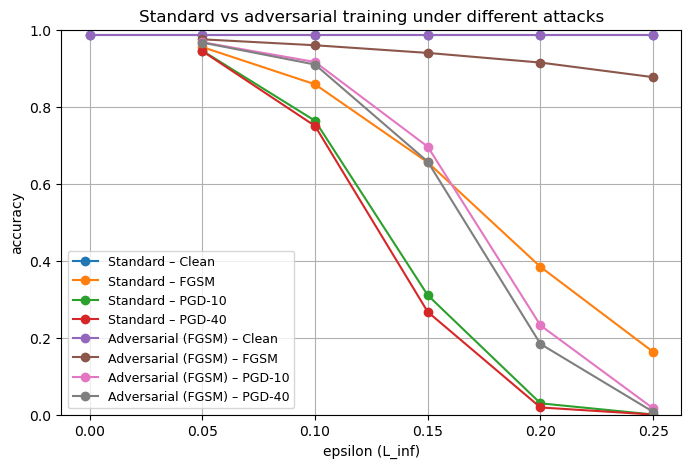

In [18]:
# Run the same sweep for both models and compare side-by-side

df_std = sweep_attacks(model, test_loader, eps_list, pgd_steps_list=(10, 40), max_batches=None)
df_std["training"] = "Standard"

df_adv = sweep_attacks(adv_model, test_loader, eps_list, pgd_steps_list=(10, 40), max_batches=None)
df_adv["training"] = "Adversarial (FGSM)"

df_all = pd.concat([df_std, df_adv], ignore_index=True)

# Table: rows = (training, epsilon), cols = attack, values = accuracy
table2 = df_all.pivot_table(index=["training", "epsilon"], columns="attack", values="accuracy")
display(table2.style.format("{:.3f}"))

# Plot: one curve per (training, attack)
plt.figure(figsize=(8,5))
for training in df_all["training"].unique():
    sub = df_all[df_all["training"] == training]
    for attack in sub["attack"].unique():
        sub2 = sub[sub["attack"] == attack].sort_values("epsilon")
        plt.plot(sub2["epsilon"], sub2["accuracy"], marker="o", label=f"{training} â€“ {attack}")

plt.xlabel("epsilon (L_inf)")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.grid(True)
plt.legend(fontsize=9)
plt.title("Standard vs adversarial training under different attacks")
plt.show()


# Part III: CIFAR-10 Extension

This section repeats the workflow on CIFAR-10 so the same robustness ideas can be tested on a more challenging dataset.


# CIFAR-10: repeat the same experiments

So far we used MNIST (grayscale, $28\times 28$). Now we repeat the same workflow on **CIFAR-10** (RGB, $32\times 32$):

1) Train a standard CNN on clean CIFAR-10  
2) Evaluate robustness vs $\varepsilon$ for FGSM and PGD  
3) Train an adversarially trained CNN (FGSM adversarial training)  
4) Compare robustness curves: standard vs adversarial training

Notes:
- We keep inputs in the pixel range $[0,1]$ (no dataset normalization) so the clipping/projection steps are the same as in MNIST.
- CIFAR-10 is harder than MNIST, so accuracy will be lower for a small CNN trained for only a few epochs.


In [19]:
from torch.utils.data import DataLoader

# CIFAR-10 in [0,1]
cifar_transform = transforms.Compose([transforms.ToTensor()])

cifar_train_ds = datasets.CIFAR10(root="./data", train=True, download=True, transform=cifar_transform)
cifar_test_ds  = datasets.CIFAR10(root="./data", train=False, download=True, transform=cifar_transform)

# DataLoader stability: use num_workers=0 (safe on macOS / Python 3.12)
cifar_train_loader = DataLoader(cifar_train_ds, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=torch.cuda.is_available())
cifar_test_loader  = DataLoader(cifar_test_ds,  batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())

cifar_classes = cifar_train_ds.classes
cifar_classes

100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 170M/170M [01:43<00:00, 1.65MB/s] 


['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [20]:
class SmallCIFARCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, 3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv3 = nn.Conv2d(128, 128, 3, padding=1)
        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)
        self.fc1   = nn.Linear(256 * 2 * 2, 256)
        self.fc2   = nn.Linear(256, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)   # 32 -> 16
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)   # 16 -> 8
        x = F.relu(self.conv3(x))
        x = F.max_pool2d(x, 2)   # 8 -> 4
        x = F.relu(self.conv4(x))
        x = F.max_pool2d(x, 2)   # 4 -> 2
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

cifar_model = SmallCIFARCNN().to(device)
cifar_opt = torch.optim.Adam(cifar_model.parameters(), lr=1e-3)

In [21]:
# Train a few epochs (increase epochs for better accuracy)
cifar_epochs = 5
for epoch in range(cifar_epochs):
    loss = train_one_epoch(cifar_model, cifar_train_loader, cifar_opt)
    acc = eval_clean(cifar_model, cifar_test_loader)
    print(f"[CIFAR-10 clean] epoch={epoch+1} loss={loss:.4f} test_acc={acc*100:.2f}%")

[CIFAR-10 clean] epoch=1 loss=1.6385 test_acc=53.89%
[CIFAR-10 clean] epoch=2 loss=1.1665 test_acc=60.78%
[CIFAR-10 clean] epoch=3 loss=0.9632 test_acc=67.38%
[CIFAR-10 clean] epoch=4 loss=0.8088 test_acc=70.83%
[CIFAR-10 clean] epoch=5 loss=0.7023 test_acc=71.62%


## CIFAR-10 robustness: accuracy vs $\varepsilon$ (different attacks)

We evaluate the clean-trained CIFAR-10 model under the same attacks:

- Clean (no attack)
- FGSM
- PGD-10
- PGD-40


attack,Clean,FGSM,PGD-10,PGD-40
epsilon,,,,
0.000000,0.716,nan,nan,nan
0.001961,0.716,0.629,0.624,0.624
0.003922,0.716,0.545,0.530,0.528
0.007843,0.716,0.403,0.351,0.337
0.015686,0.716,0.202,0.105,0.088
0.031373,0.716,0.056,0.004,0.002


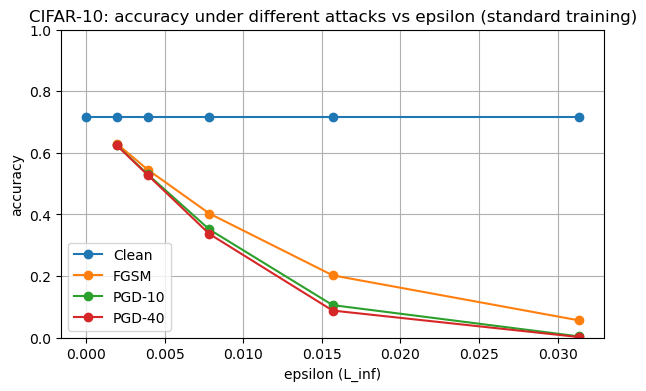

In [22]:
# Sweep attacks for the CIFAR-10 clean-trained model
cifar_eps_list = [0.0, 0.5/255, 1/255, 2/255, 4/255, 8/255]  # common CIFAR scales
df_cifar_std = sweep_attacks(cifar_model, cifar_test_loader, cifar_eps_list, pgd_steps_list=(10, 40), max_batches=None)
df_cifar_std["training"] = "Standard"

table_cifar_std = df_cifar_std.pivot_table(index="epsilon", columns="attack", values="accuracy")
display(table_cifar_std.style.format("{:.3f}"))

plt.figure(figsize=(7,4))
for col in table_cifar_std.columns:
    plt.plot(table_cifar_std.index, table_cifar_std[col], marker="o", label=col)
plt.xlabel("epsilon (L_inf)")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.grid(True)
plt.legend()
plt.title("CIFAR-10: accuracy under different attacks vs epsilon (standard training)")
plt.show()


## CIFAR-10 adversarial training (FGSM)

We adversarially train a second CIFAR-10 model using FGSM examples with a fixed budget $\varepsilon$.

We then compare robustness curves: standard vs adversarial training.

In [23]:
cifar_adv_model = SmallCIFARCNN().to(device)
cifar_adv_opt = torch.optim.Adam(cifar_adv_model.parameters(), lr=1e-3)

cifar_adv_eps = 8/255   # typical training budget on CIFAR-10
cifar_lam = 0.5
cifar_adv_epochs = 5

for epoch in range(cifar_adv_epochs):
    loss = train_one_epoch_adv_fgsm(cifar_adv_model, cifar_train_loader, cifar_adv_opt, eps=cifar_adv_eps, lam=cifar_lam)
    acc = eval_clean(cifar_adv_model, cifar_test_loader)
    print(f"[CIFAR-10 adv-train] epoch={epoch+1} loss={loss:.4f} clean_test_acc={acc*100:.2f}%")

[CIFAR-10 adv-train] epoch=1 loss=1.9745 clean_test_acc=45.00%
[CIFAR-10 adv-train] epoch=2 loss=1.6952 clean_test_acc=53.11%
[CIFAR-10 adv-train] epoch=3 loss=1.5887 clean_test_acc=56.05%
[CIFAR-10 adv-train] epoch=4 loss=1.5128 clean_test_acc=57.88%
[CIFAR-10 adv-train] epoch=5 loss=1.4598 clean_test_acc=60.41%


## CIFAR-10: standard vs adversarial training (side-by-side)

Same evaluation as before, but now comparing both CIFAR-10 models.

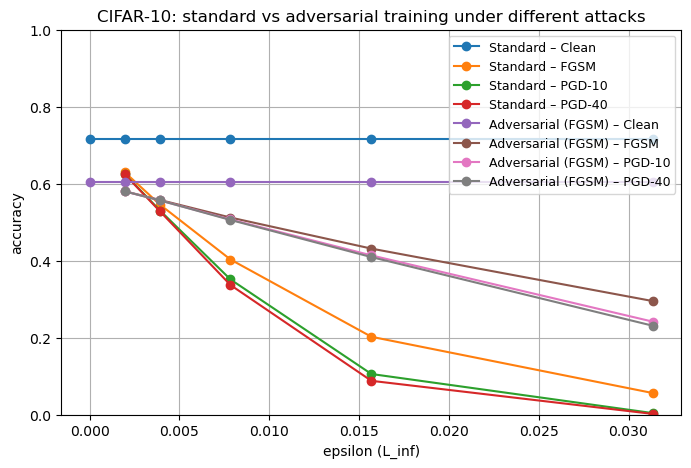

In [24]:
df_cifar_adv = sweep_attacks(cifar_adv_model, cifar_test_loader, cifar_eps_list, pgd_steps_list=(10, 40), max_batches=None)
df_cifar_adv["training"] = "Adversarial (FGSM)"

df_cifar_all = pd.concat([df_cifar_std, df_cifar_adv], ignore_index=True)

table_cifar = df_cifar_all.pivot_table(index=["training", "epsilon"], columns="attack", values="accuracy")
display(table_cifar.style.format("{:.3f}"))

plt.figure(figsize=(8,5))
for training in df_cifar_all["training"].unique():
    sub = df_cifar_all[df_cifar_all["training"] == training]
    for attack in sub["attack"].unique():
        sub2 = sub[sub["attack"] == attack].sort_values("epsilon")
        plt.plot(sub2["epsilon"], sub2["accuracy"], marker="o", label=f"{training} â€“ {attack}")

plt.xlabel("epsilon (L_inf)")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.grid(True)
plt.legend(fontsize=9)
plt.title("CIFAR-10: standard vs adversarial training under different attacks")
plt.show()